In [15]:
import sys
import os

# 1. Add 'src' to your Python path so we can resolve the 'google.adk.scope' imports
sys.path.insert(0, os.path.abspath("src"))

# 2. (Optional but recommended) Auto-reload modules when you change the .py files
%load_ext autoreload
%autoreload 2

# 3. Import the required files
from google.adk.scope import features_pb2
from google.adk.scope.utils import similarity
from google.protobuf import text_format
import pandas as pd
import numpy as np
import logging

logging.basicConfig(level=logging.DEBUG)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of google.adk.scope.features_pb2 failed: Traceback (most recent call last):
  File "/Users/shahins/.pyenv/versions/3.12.4/envs/main/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 325, in check
    superreload(m, reload, self.old_objects)
  File "/Users/shahins/.pyenv/versions/3.12.4/envs/main/lib/python3.12/site-packages/IPython/extensions/autoreload.py", line 580, in superreload
    module = reload(module)
             ^^^^^^^^^^^^^^
  File "/Users/shahins/.pyenv/versions/3.12.4/lib/python3.12/importlib/__init__.py", line 131, in reload
    _bootstrap._exec(spec, module)
  File "<frozen importlib._bootstrap>", line 866, in _exec
  File "<frozen importlib._bootstrap_external>", line 995, in exec_module
  File "<frozen importlib._bootstrap>", line 488, in _call_with_frames_removed
  File "/Users/shahins/projects/adk/adk-scope/src/google/adk/scope/features_pb2.py", line 27, in <module>
    DESCRIPTOR = _descriptor_pool.Default().AddSerializedFile(b'\n\x0

In [16]:
pg = pd.read_csv('./output/py_go.csv').sort_values(by = ['score', 'type'], ascending=False).copy()
pj = pd.read_csv('./output/py_java.csv').sort_values(by = ['score', 'type'], ascending=False).copy()
pt = pd.read_csv('./output/py_ts.csv').sort_values(by = ['score', 'type'], ascending=False).copy()

pg.shape, pj.shape, pt.shape

((1578, 10), (2377, 10), (1460, 10))

In [17]:
pg['score'].describe()

count    1578.000000
mean        0.291746
std         0.167895
min         0.000000
25%         0.231607
50%         0.293370
75%         0.381544
max         0.985000
Name: score, dtype: float64

In [18]:
pj['score'].describe()

count    2377.000000
mean        0.279072
std         0.319965
min         0.000000
25%         0.000000
50%         0.266099
75%         0.452338
max         1.000000
Name: score, dtype: float64

In [19]:
pt['score'].describe()

count    1460.000000
mean        0.445758
std         0.256881
min         0.000000
25%         0.272312
50%         0.360000
75%         0.527648
max         1.000000
Name: score, dtype: float64

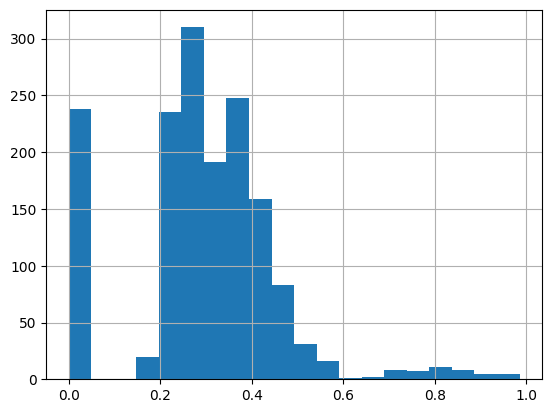

In [20]:
pg['score'].hist(bins=20);

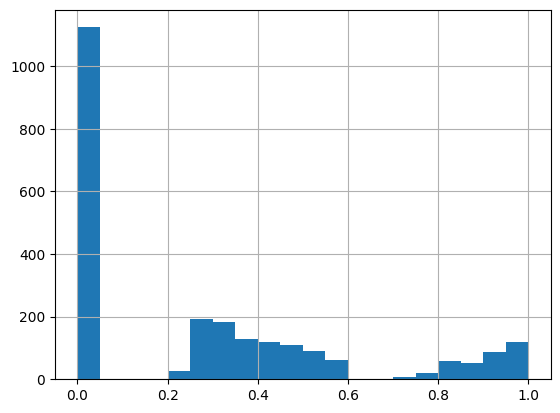

In [21]:
pj['score'].hist(bins=20);

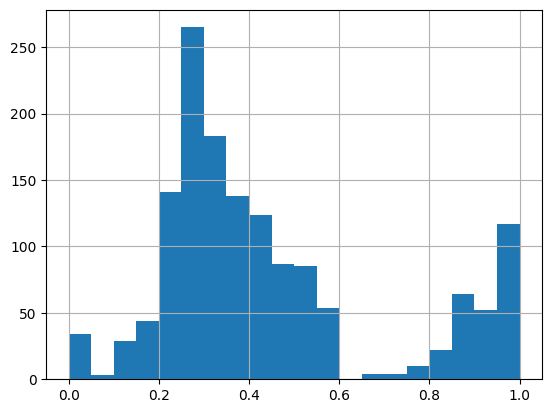

In [22]:
pt['score'].hist(bins=20);

In [23]:
# PYTHON <-> GO:
# 0.6 <= GOOD
# 0.5 < AVERAGE <= 0.6
# BAD <= 0.5 
LOWER, UPPER = 0.4599, 0.4999
print(len(pg[(LOWER < pg['score']) & (pg['score'] < UPPER)]))
pg[(LOWER < pg['score']) & (pg['score'] < UPPER)].head(5)

52


,python_namespace,python_member_of,python_name,go_namespace,go_member_of,go_name,type,score,match,confidence
430,agents,NaN,from_config,internal.agent.parentmap,NaN,FromContext,function,0.498214,False,high
648,sessions,InMemorySessionService,get_session,memory,InMemoryService,AddSession,method,0.497182,False,high
442,utils,NaN,is_gemini_2_or_above,internal.llminternal.googlellm,NaN,IsGemini25OrLower,function,0.495882,False,high
357,agents,BaseAgent,root_agent,agent,Loader,RootAgent,method,0.495000,False,high
764,evaluation,InvocationEvent,InvocationEvent,internal.context,InvocationContext,NewInvocationContext,constructor,0.493333,False,high


In [24]:
# PYTHON <-> JAVA:
# 0.6 <= GOOD
# BAD <= 0.6
LOWER, UPPER = 0.4999, 0.5999
print(len(pj[(LOWER < pj['score']) & (pj['score'] < UPPER)]))
pj[(LOWER < pj['score']) & (pj['score'] < UPPER)].head(5)

147


,python_namespace,python_member_of,python_name,java_namespace,java_member_of,java_name,type,score,match,confidence
906,code_executors,CodeExecutionResult,CodeExecutionResult,codeexecutors,CodeExecutionUtils,CodeExecutionUtils,constructor,0.598810,False,high
632,sessions,SqliteSessionService,get_session,sessions,BaseSessionService,createSession,method,0.596104,False,high
55,tools,AuthenticatedFunctionTool,run_async,tools,FunctionTool,runAsync,method,0.594444,False,high
365,agents,SequentialAgentState,SequentialAgentState,agents,SequentialAgentConfig,SequentialAgentConfig,constructor,0.593478,False,high
907,code_executors,CodeExecutionInput,CodeExecutionInput,codeexecutors,CodeExecutionUtils,CodeExecutionUtils,constructor,0.591667,False,high


In [25]:
# PYTHON <-> TS:
# 0.7 <= GOOD
# 0.55 < AVERAGE <= 0.7
# BAD <= 0.55
LOWER, UPPER = 0.55, 0.7
print(len(pt[(LOWER < pt['score']) & (pt['score'] < UPPER)]))
pt[(LOWER < pt['score']) & (pt['score'] < UPPER)].tail(5)

55


,python_namespace,python_member_of,python_name,typescript_namespace,typescript_member_of,typescript_name,type,score,match,confidence
110,tools,SetModelResponseTool,run_async,tools,GoogleSearchTool,runAsync,method,0.554348,False,high
1007,tools.pubsub,PubSubToolset,get_tools,tools.mcp,MCPToolset,getTools,method,0.553750,False,high
1008,tools.pubsub,PubSubToolset,close,tools.mcp,MCPToolset,close,method,0.553750,False,high
209,plugins,BigQueryAgentAnalyticsPlugin,before_tool_callback,plugins,SecurityPlugin,beforeToolCallback,method,0.553125,False,high
760,evaluation,NaN,get_all_tool_responses,events,NaN,getFunctionResponses,function,0.552273,False,high


In [26]:
pg[['match', 'confidence', 'type', 'score']].groupby(['match', 'confidence', 'type']).count()

score
match confidence type              
False high       constructor    409
                 function       268
                 method         855
True  high       constructor      1
                 function         2
                 method          24
      low        constructor      8
                 function         4
                 method           7